# 00a — EDA: population & census inputs

**What this notebook does.** It looks at every *people-side* input before the pipeline
uses it, so structural surprises (duplicate keys, values that are really "suppressed",
missing map shapes, string-vs-number join traps) are found now and not halfway through
notebook 06. Nothing here is cleaned or joined for keeps — this is a read-only tour that
ends in a data-quality list telling notebooks 01 and 02 exactly what to handle.

**What it reads** (raw / external only):

| dataframe | file | what it is |
|---|---|---|
| `bushtel_communities_gdf` | `data/raw/bushtel/Com_BushTel_Profile_CMC_2024.json` | 792 NT communities, as points — the project spine |
| `census_g01_sa1_df` | `.../SA1/NT/2021Census_G01_NT_SA1.csv` | persons by sex, per SA1 (the only real population) |
| `census_g02_sa1_df` | `.../SA1/NT/2021Census_G02_NT_SA1.csv` | medians & averages per SA1 (income, household size) |
| `sa1_polygons_gdf` | `.../SA1_2021_AUST_GDA2020_SHP/...shp` | NT SA1 boundary polygons (the population reporting unit) |
| `iloc_polygons_gdf` | `.../ILOC_2021_AUST_GDA2020_SHP/...shp` | NT Indigenous Location polygons |
| `ra_workbook_df` | `.../RA_2021_AUST.xlsx` | SA1 → Remoteness Area lookup |

**What it writes.** Nothing except PNG plots, saved to `docs/eda/` in the last cell. No
data files.

**Why it exists.** The last build carried a few myths ("there is a duplicate
`community_id`", "some SA1s have null income") that turn out to be miscounts or ABS
suppression. This notebook settles each one with the data itself.

In [1]:
# Every import for the whole notebook lives in this cell.
%matplotlib inline
import json
import os
from pathlib import Path

# These notebooks live in notebooks/; every data path below is written relative to the
# repo root, so make the repo root the working directory if we started inside notebooks/.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

In [2]:
# Every raw/external file the notebook needs is read here, one line each. Nothing is
# opened anywhere else below.

# --- file locations (this notebook reads nothing from data/new_processed/) ---
BUSHTEL_JSON   = "data/raw/bushtel/Com_BushTel_Profile_CMC_2024.json"
CENSUS_G01_CSV = "data/raw/census_gcp_2021/2021_GCP_all_for_NT_short-header/2021 Census GCP All Geographies for NT/SA1/NT/2021Census_G01_NT_SA1.csv"
CENSUS_G02_CSV = "data/raw/census_gcp_2021/2021_GCP_all_for_NT_short-header/2021 Census GCP All Geographies for NT/SA1/NT/2021Census_G02_NT_SA1.csv"
SA1_SHP        = "data/external/abs_boundaries/SA1_2021_AUST_GDA2020_SHP/SA1_2021_AUST_GDA2020.shp"
ILOC_SHP       = "data/external/abs_boundaries/ILOC_2021_AUST_GDA2020_SHP/ILOC_2021_AUST_GDA2020.shp"
RA_XLSX        = "data/external/abs_boundaries/RA_2021_AUST.xlsx"

# The ABS shapefiles are national. This WHERE clause makes GDAL hand back only NT rows
# at read time, so we never hold 61,845 polygons in memory.
NT_WHERE = "STE_NAME21 = 'Northern Territory'"

# SA1 codes are 11-digit identifiers. Pandas will happily read them as int64; every table
# that keeps them as text then fails to join silently. Force string on every read.
SA1_CODE_DTYPE = {"SA1_CODE_2021": str}

bushtel_communities_gdf = gpd.read_file(BUSHTEL_JSON)                        # 792 point features, EPSG:4326
census_g01_sa1_df       = pd.read_csv(CENSUS_G01_CSV, dtype=SA1_CODE_DTYPE)  # persons by sex, per SA1
census_g02_sa1_df       = pd.read_csv(CENSUS_G02_CSV, dtype=SA1_CODE_DTYPE)  # medians & averages, per SA1
sa1_polygons_gdf        = gpd.read_file(SA1_SHP,  where=NT_WHERE)            # NT SA1 polygons, EPSG:7844
iloc_polygons_gdf       = gpd.read_file(ILOC_SHP, where=NT_WHERE)            # NT ILOC polygons, EPSG:7844
ra_workbook_df          = pd.read_excel(RA_XLSX, sheet_name="SA1_RA_2021_AUST", dtype=SA1_CODE_DTYPE)

# The only thing this notebook produces: PNGs. Figures worth keeping are registered in
# this dict as they are made, and written once in the last cell.
EDA_PLOT_DIR = Path("docs/eda")
EDA_PLOT_DIR.mkdir(parents=True, exist_ok=True)
eda_figures = {}

print("rows read:")
print(f"  bushtel_communities_gdf : {len(bushtel_communities_gdf):>5}")
print(f"  census_g01_sa1_df       : {len(census_g01_sa1_df):>5}")
print(f"  census_g02_sa1_df       : {len(census_g02_sa1_df):>5}")
print(f"  sa1_polygons_gdf        : {len(sa1_polygons_gdf):>5}")
print(f"  iloc_polygons_gdf       : {len(iloc_polygons_gdf):>5}")
print(f"  ra_workbook_df (all AU) : {len(ra_workbook_df):>5}")

rows read:
  bushtel_communities_gdf :   792
  census_g01_sa1_df       :   649
  census_g02_sa1_df       :   649
  sa1_polygons_gdf        :   649
  iloc_polygons_gdf       :   189
  ra_workbook_df (all AU) : 61845


---
## A. BushTel communities — the spine

Every people fact hangs off a village and every infrastructure fact is measured *from* a
village, so this table's key has to be trustworthy. First: what is one row, and what
columns are there?

In [3]:
print("shape:", bushtel_communities_gdf.shape)
print("CRS:", bushtel_communities_gdf.crs)
print("geometry types:", bushtel_communities_gdf.geom_type.value_counts().to_dict())
print("columns:", list(bushtel_communities_gdf.columns))
bushtel_communities_gdf[["community_id", "community_name", "community_type",
                         "latitude", "longitude", "population_count", "population_source"]].head()

shape: (792, 17)
CRS: EPSG:4326
geometry types: {'Point': 792}
columns: ['bushtel_url', 'community_name', 'land_council', 'latitude', 'local_govt_council', 'ward', 'ntg_region', 'community_id', 'main_language', 'community_aliases', 'population_count', 'community_type', 'electorate', 'population_source', 'objectid', 'longitude', 'geometry']


,community_id,community_name,community_type,latitude,longitude,population_count,population_source
0,1022,10 MILE,Family Outstation,-20.40628,134.75934,8.0,Homelands Service Provider Report 2023
1,1004,10 MILE OUTSTATION,Family Outstation,-22.46667,132.37658,10.0,Homelands Service Provider Report 2023
2,783,16 MILE CAMP,Family Outstation,-23.45764,133.83248,NaN,Not recorded
3,24993,20 MILE,Family Outstation,-16.08535,136.54826,6.0,Homelands Service Provider Report 2023
4,1006,4 MILE CAMP,Family Outstation,-11.77798,130.59548,7.0,Homelands Service Provider Report 2023


### A.1 The reported "duplicate `community_id` / 793 rows vs 792 features"

Chase it down rather than assume. If BushTel really has a repeated id, notebook 01 needs a
dedupe rule; if a village sits on a polygon boundary, the spatial join could fan one
village into two rows.

In [4]:
n_features = len(bushtel_communities_gdf)
n_unique_id = bushtel_communities_gdf["community_id"].nunique()
print(f"features: {n_features}")
print(f"distinct community_id: {n_unique_id}")
print(f"community_id.is_unique: {bushtel_communities_gdf['community_id'].is_unique}")

dup_ids = bushtel_communities_gdf["community_id"].value_counts()
dup_ids = dup_ids[dup_ids > 1]
print(f"community_id values appearing more than once: {len(dup_ids)}")
print(dup_ids)

# Does the within-join to SA1 / ILOC fan any village into >1 row? (the other way a 793 could appear)
_pts = bushtel_communities_gdf.to_crs("EPSG:4326")[["community_id", "geometry"]]
for label, shp in [("SA1", SA1_SHP), ("ILOC", ILOC_SHP)]:
    _poly = gpd.read_file(shp, where=NT_WHERE)[["geometry"]].to_crs("EPSG:4326")
    _j = gpd.sjoin(_pts, _poly, how="left", predicate="within")
    print(f"within-join to {label}: {len(_pts)} villages -> {len(_j)} rows, "
          f"{_j['community_id'].isna().sum()} unmatched, "
          f"{int(_j['community_id'].duplicated().sum())} villages matched >1 polygon")

print()
print("CONCLUSION: 792 features, 792 distinct community_id, joins are 1:1. The '793' is a")
print("line count that included the CSV header row. No dedupe step is needed in nb 01.")

features: 792
distinct community_id: 792
community_id.is_unique: True
community_id values appearing more than once: 0
Series([], Name: count, dtype: int64)


within-join to SA1: 792 villages -> 792 rows, 0 unmatched, 0 villages matched >1 polygon
within-join to ILOC: 792 villages -> 792 rows, 0 unmatched, 0 villages matched >1 polygon

CONCLUSION: 792 features, 792 distinct community_id, joins are 1:1. The '793' is a
line count that included the CSV header row. No dedupe step is needed in nb 01.


### A.2 `community_type` — the mix of places

community_type
Family Outstation    630
Major                 59
Town Camp             45
Minor                 37
Village               13
Town                   7
City                   1
Name: count, dtype: int64


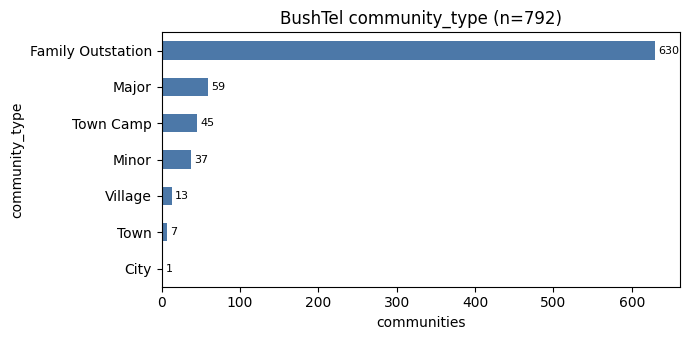

In [5]:
type_counts = bushtel_communities_gdf["community_type"].value_counts()
print(type_counts)

fig, ax = plt.subplots(figsize=(7, 3.5))
type_counts.sort_values().plot.barh(ax=ax, color="#4c78a8")
ax.set_xlabel("communities")
ax.set_title("BushTel community_type (n=792)")
for i, v in enumerate(type_counts.sort_values()):
    ax.text(v + 4, i, str(v), va="center", fontsize=8)
fig.tight_layout()
eda_figures["00a_bushtel_community_type_counts"] = fig

### A.3 `population_count` coverage and `population_source`

PROJECT_CONTEXT rule 2: BushTel population is **reference only**, never summed. Still worth
knowing how partial it is and where the numbers claim to come from.

In [6]:
has_pop = bushtel_communities_gdf["population_count"].notna()
print(f"has a BushTel population figure: {int(has_pop.sum())} / {len(bushtel_communities_gdf)}")
print(f"no figure: {int((~has_pop).sum())}")

print("\npopulation_source value counts:")
print(bushtel_communities_gdf["population_source"].value_counts(dropna=False))

print("\npopulation_source x (figure present?):")
print(pd.crosstab(bushtel_communities_gdf["population_source"], has_pop.rename("has_figure")))

print("\nfigure present, split by community_type:")
print(pd.crosstab(bushtel_communities_gdf["community_type"], has_pop.rename("has_figure")))

has a BushTel population figure: 457 / 792
no figure: 335

population_source value counts:
population_source
Homelands Service Provider Report 2023    379
Not recorded                              335
Based on ABS 2021 Census SA1               78
Name: count, dtype: int64

population_source x (figure present?):
has_figure                              False  True 
population_source                                   
Based on ABS 2021 Census SA1                0     78
Homelands Service Provider Report 2023      0    379
Not recorded                              335      0

figure present, split by community_type:
has_figure         False  True 
community_type                 
City                   1      0
Family Outstation    272    358
Major                  0     59
Minor                  4     33
Town                   7      0
Town Camp             45      0
Village                6      7


### A.4 `community_aliases` — used later for name matching (nb 05 / 06)

Notebook 06 matches villages to coverage-guide place names on `community_name` *or*
`community_aliases`. So we need to know: how many rows carry a real alias, how many carry a
"nothing here" sentinel, and whether the field is multi-valued.

In [7]:
alias = bushtel_communities_gdf["community_aliases"].fillna("").str.strip()
is_sentinel = alias.str.contains("No aliases recorded", case=False)
has_real_alias = (alias != "") & ~is_sentinel

print(f"non-empty alias string      : {int((alias != '').sum())}")
print(f"  of which the sentinel 'No aliases recorded with NTG DIPL': {int(is_sentinel.sum())}")
print(f"  of which a real alias      : {int(has_real_alias.sum())}")
print(f"multi-valued (comma-separated): {int(alias.str.contains(',').sum())}")
print("\nsample of real aliases:")
for s in alias[has_real_alias].head(15):
    print("   ", s)

non-empty alias string      : 792
  of which the sentinel 'No aliases recorded with NTG DIPL': 180
  of which a real alias      : 612
multi-valued (comma-separated): 376

sample of real aliases:
    PALPANG,TEN MILE
    TEN MILE OUTSTATION
    ATHENGE-LHERE,BOND SPRINGS
    WUMAYALINJA
    FOUR MILE CAMP,NGUIU 4 MILE CAMP
    5 MILE
    ACACIA GAP
    TREPANG BAY
    WOOLA,WOOLLA
    APIWENTYE
    MORRIS SOAK
    4 MILE,FOUR MILE
    ALAMIRR
    TURNERS CAMP
    CAPE BARROW


### A.5 Villages on a map, coloured by type

Straight-line sanity check that the points land inside the NT and that the type field
isn't scrambled (towns near the highways/coast, outstations spread through the interior).

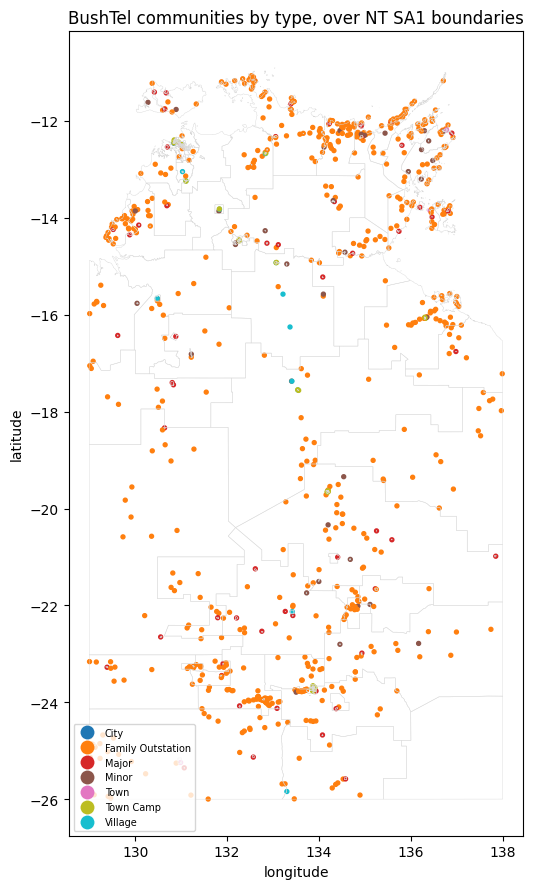

In [8]:
sa1_outline_4326 = sa1_polygons_gdf.dropna(subset=["geometry"]).to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(7.5, 9))
sa1_outline_4326.boundary.plot(ax=ax, color="0.85", linewidth=0.3)
bushtel_communities_gdf.plot(ax=ax, column="community_type", legend=True,
                             markersize=8, cmap="tab10",
                             legend_kwds={"fontsize": 7, "loc": "lower left"})
ax.set_title("BushTel communities by type, over NT SA1 boundaries")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["00a_bushtel_villages_by_type_map"] = fig

---
## B. Census G01 & G02 at SA1 — the only real population

`Tot_P_P` (total persons) at SA1 is the population number the whole project rests on.

In [9]:
print("G01 shape:", census_g01_sa1_df.shape)
print("G01 SA1 code sample:", census_g01_sa1_df["SA1_CODE_2021"].head(3).tolist())
print("G01 SA1 code all 11 chars:", bool((census_g01_sa1_df["SA1_CODE_2021"].str.len() == 11).all()))

# show the string-vs-int trap explicitly: same file, no dtype override
_int_read = pd.read_csv(CENSUS_G01_CSV)["SA1_CODE_2021"]
print(f"without dtype=str, SA1_CODE_2021 reads as {_int_read.dtype} (e.g. {_int_read.iloc[0]!r}) "
      f"-> would not join to a string key")

print("\nTot_P_P distribution across the 649 NT SA1s:")
print(census_g01_sa1_df["Tot_P_P"].describe())
for thr in (1, 5, 50):
    print(f"  SA1s with Tot_P_P < {thr:>2}: {int((census_g01_sa1_df['Tot_P_P'] < thr).sum())}")

G01 shape: (649, 109)
G01 SA1 code sample: ['70101100101', '70101100206', '70101100207']
G01 SA1 code all 11 chars: True
without dtype=str, SA1_CODE_2021 reads as int64 (e.g. np.int64(70101100101)) -> would not join to a string key

Tot_P_P distribution across the 649 NT SA1s:
count     649.000000
mean      358.343606
std       271.570076
min         0.000000
25%       201.000000
50%       355.000000
75%       479.000000
max      3500.000000
Name: Tot_P_P, dtype: float64
  SA1s with Tot_P_P <  1: 27
  SA1s with Tot_P_P <  5: 34
  SA1s with Tot_P_P < 50: 67


### B.1 `Tot_P_P` histogram (linear and log)

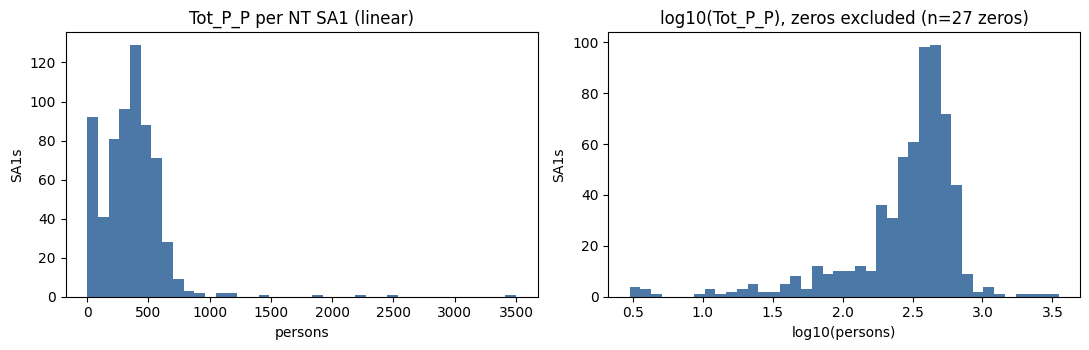

In [10]:
totpp = census_g01_sa1_df["Tot_P_P"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(totpp, bins=40, color="#4c78a8")
axes[0].set_title("Tot_P_P per NT SA1 (linear)")
axes[0].set_xlabel("persons"); axes[0].set_ylabel("SA1s")

# log x needs positive values; show the zeros as a separate labelled bar
nonzero = totpp[totpp > 0]
axes[1].hist(np.log10(nonzero), bins=40, color="#4c78a8")
axes[1].set_title(f"log10(Tot_P_P), zeros excluded (n={int((totpp==0).sum())} zeros)")
axes[1].set_xlabel("log10(persons)"); axes[1].set_ylabel("SA1s")
fig.tight_layout()
eda_figures["00a_census_totpp_hist"] = fig

### B.2 Where are the empty / tiny SA1s?

If they were all in the remote interior that would matter for the gap story. Map them, and
list the SA2s they sit in.

SA2s containing the 27 zero-population SA1s:
SA2_NAME21
Larapinta                        3
Palmerston - South               2
Tennant Creek                    2
Howard Springs                   2
Darwin City                      1
East Point                       1
Buffalo Creek                    1
Alawa                            1
Woolner - Bayview - Winnellie    1
Ludmilla - The Narrows           1
Rapid Creek                      1
Rosebery - Bellamack             1
Flynn (NT)                       1
Wagaman                          1
Mount Johns                      1
Name: count, dtype: int64

-> by count most sit in urban SA2s (Darwin/Palmerston/Larapinta) and are non-residential
   parcels; the map shows a handful are also large remote SA1s (parks, borders).


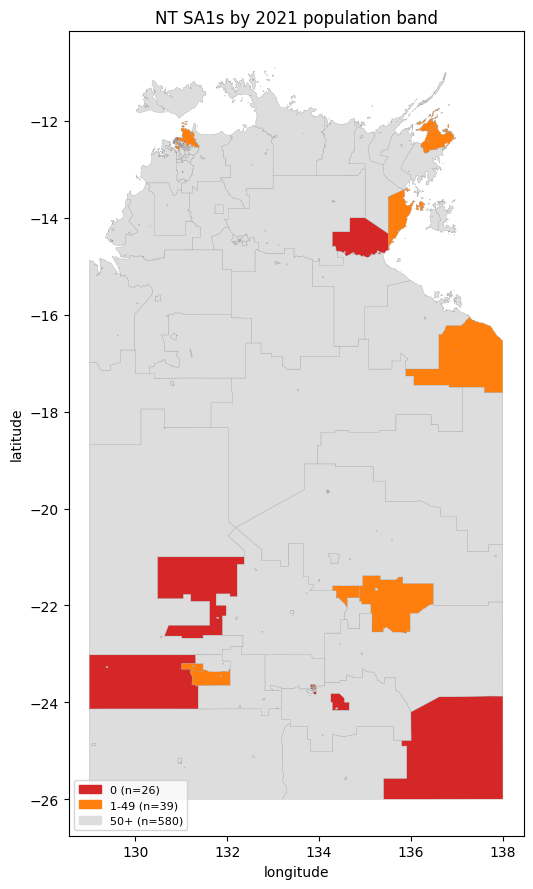

In [11]:
sa1_pop_gdf = sa1_polygons_gdf.merge(
    census_g01_sa1_df[["SA1_CODE_2021", "Tot_P_P"]],
    left_on="SA1_CODE21", right_on="SA1_CODE_2021", how="left",
)

def pop_band(p):
    if pd.isna(p):        return "no census row"
    if p == 0:            return "0"
    if p < 50:            return "1-49"
    return "50+"

sa1_pop_gdf["pop_band"] = sa1_pop_gdf["Tot_P_P"].map(pop_band)
print("SA2s containing the 27 zero-population SA1s:")
print(sa1_pop_gdf.loc[sa1_pop_gdf["Tot_P_P"] == 0, "SA2_NAME21"].value_counts().head(15))
print("\n-> by count most sit in urban SA2s (Darwin/Palmerston/Larapinta) and are non-residential")
print("   parcels; the map shows a handful are also large remote SA1s (parks, borders).")

band_colours = {"0": "#d62728", "1-49": "#ff7f0e", "50+": "#dddddd", "no census row": "#000000"}
fig, ax = plt.subplots(figsize=(7.5, 9))
legend_handles = []
for band, colour in band_colours.items():
    sub = sa1_pop_gdf[(sa1_pop_gdf["pop_band"] == band) & sa1_pop_gdf["geometry"].notna()]
    if len(sub):
        sub.plot(ax=ax, color=colour, edgecolor="0.6", linewidth=0.2)
        legend_handles.append(mpatches.Patch(color=colour, label=f"{band} (n={len(sub)})"))
ax.legend(handles=legend_handles, fontsize=8, loc="lower left")
ax.set_title("NT SA1s by 2021 population band")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["00a_census_empty_tiny_sa1_map"] = fig

### B.3 Which BushTel villages sit in a *suppressed* SA1 (`Tot_P_P < 5`)?

This is the reason nb 02 **keeps** the suppressed SA1s instead of dropping them: real,
inhabited outstations fall inside SA1s the census has adjusted to ~0. Dropping the SA1
would strand those villages with no population reference at all.

In [12]:
_villages_sa1 = gpd.sjoin(
    bushtel_communities_gdf.to_crs("EPSG:4326")[["community_id", "community_name", "community_type", "geometry"]],
    sa1_polygons_gdf.dropna(subset=["geometry"])[["SA1_CODE21", "SA2_NAME21", "geometry"]].to_crs("EPSG:4326"),
    how="left", predicate="within",
).drop(columns="index_right").merge(
    census_g01_sa1_df[["SA1_CODE_2021", "Tot_P_P"]], left_on="SA1_CODE21", right_on="SA1_CODE_2021", how="left")

suppressed_villages = _villages_sa1[_villages_sa1["Tot_P_P"] < 5].sort_values(["SA1_CODE21", "community_name"])
print(f"{len(suppressed_villages)} BushTel villages fall in {suppressed_villages['SA1_CODE21'].nunique()} "
      f"SA1s with Tot_P_P < 5 (all are Tot_P_P == 0):\n")
print(suppressed_villages.groupby(["SA1_CODE21", "SA2_NAME21", "Tot_P_P"])
      .size().rename("n_villages").reset_index().to_string(index=False))
print("\nby community_type:", suppressed_villages["community_type"].value_counts().to_dict())
print("\nfull list:")
print(suppressed_villages[["community_id", "community_name", "SA1_CODE21", "SA2_NAME21"]].to_string(index=False))
print("\n-> in villages.csv these 30 keep their sa1_code and get pop_census_2021 = 0; the SA1 "
      "row in sa1_report carries census_pop_suppressed = True so downstream code can see it.")

30 BushTel villages fall in 4 SA1s with Tot_P_P < 5 (all are Tot_P_P == 0):

 SA1_CODE21           SA2_NAME21  Tot_P_P  n_villages
70201105205    Sandover - Plenty        0           1
70201105311               Tanami        0           8
70201105402 Yuendumu - Anmatjere        0          11
70205106609                 Gulf        0          10

by community_type: {'Family Outstation': 30}

full list:
 community_id   community_name  SA1_CODE21           SA2_NAME21
          133  PHILLIPSON BORE 70201105205    Sandover - Plenty
           49           ILPILI 70201105311               Tanami
           54           ININTI 70201105311               Tanami
          764            MUYIN 70201105311               Tanami
          125           NGUMAN 70201105311               Tanami
          763          NGUTJUL 70201105311               Tanami
          136        PINPIRNGA 70201105311               Tanami
           62            TINKI 70201105311               Tanami
          196      

### B.4 G02 — median household income and average household size, and the "nulls"

Reported before as "null income for some SA1s". Check whether they are actually null or
whether the ABS has zeroed them for confidentiality (small counts are suppressed).

G02 shape: (649, 9)
Median_tot_hhd_inc_weekly : NaN=0, ==0=34, median=2038, max=4625
Average_household_size     : NaN=0, ==0=33, median=2.8, max=7.7

of the 34 income==0 SA1s, 26 also have Tot_P_P < 5 -> these are ABS-suppressed small-count SA1s, not missing data


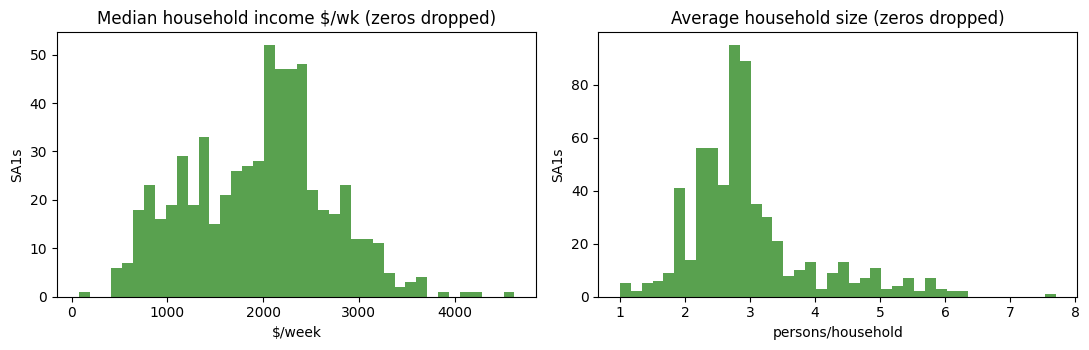

In [13]:
g02 = census_g02_sa1_df
income = pd.to_numeric(g02["Median_tot_hhd_inc_weekly"], errors="coerce")
hhsize = pd.to_numeric(g02["Average_household_size"], errors="coerce")

print("G02 shape:", g02.shape)
print(f"Median_tot_hhd_inc_weekly : NaN={int(income.isna().sum())}, ==0={int((income==0).sum())}, "
      f"median={income[income>0].median():.0f}, max={income.max():.0f}")
print(f"Average_household_size     : NaN={int(hhsize.isna().sum())}, ==0={int((hhsize==0).sum())}, "
      f"median={hhsize[hhsize>0].median():.1f}, max={hhsize.max():.1f}")

# are the zeros the same tiny SA1s as in G01?
z = g02.loc[income == 0, "SA1_CODE_2021"]
tiny = census_g01_sa1_df.loc[census_g01_sa1_df["Tot_P_P"] < 5, "SA1_CODE_2021"]
print(f"\nof the {len(z)} income==0 SA1s, {z.isin(set(tiny)).sum()} also have Tot_P_P < 5 "
      f"-> these are ABS-suppressed small-count SA1s, not missing data")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(income[income > 0], bins=40, color="#59a14f")
axes[0].set_title("Median household income $/wk (zeros dropped)")
axes[0].set_xlabel("$/week"); axes[0].set_ylabel("SA1s")
axes[1].hist(hhsize[hhsize > 0], bins=40, color="#59a14f")
axes[1].set_title("Average household size (zeros dropped)")
axes[1].set_xlabel("persons/household"); axes[1].set_ylabel("SA1s")
fig.tight_layout()
eda_figures["00a_g02_income_hhsize_hist"] = fig

---
## C. SA1 polygons — the reporting geometry

Area spread, the codes with no shape at all, and the string/dtype of the join key.

NT SA1 polygons: 649 | CRS: EPSG:7844
SA1_CODE21 dtype: object | sample: ['70101100101', '70101100206', '70101100207']

SA1 codes with NO polygon: 4
 SA1_CODE21                           SA2_NAME21                           SA3_NAME21  AREASQKM21
79797979991 Migratory - Offshore - Shipping (NT) Migratory - Offshore - Shipping (NT)         NaN
79797979992 Migratory - Offshore - Shipping (NT) Migratory - Offshore - Shipping (NT)         NaN
79797979993 Migratory - Offshore - Shipping (NT) Migratory - Offshore - Shipping (NT)         NaN
79999949999                No usual address (NT)                No usual address (NT)         NaN

AREASQKM21 (645 real polygons):
count       645.000000
mean       2090.130997
std       11357.734580
min           0.011300
25%           0.195300
50%           0.456800
75%           6.708800
max      142011.340400
Name: AREASQKM21, dtype: float64


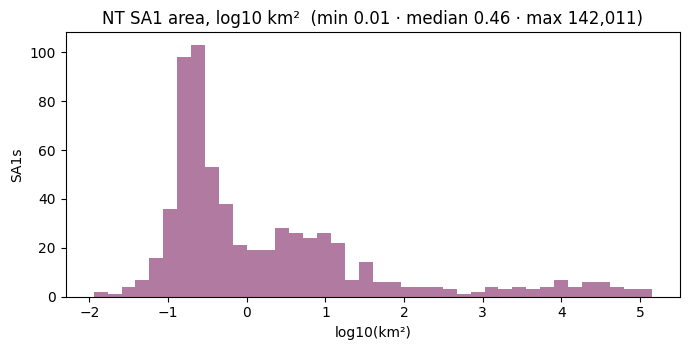

In [14]:
print("NT SA1 polygons:", len(sa1_polygons_gdf), "| CRS:", sa1_polygons_gdf.crs)
print("SA1_CODE21 dtype:", sa1_polygons_gdf["SA1_CODE21"].dtype,
      "| sample:", sa1_polygons_gdf["SA1_CODE21"].head(3).tolist())

null_geom = sa1_polygons_gdf[sa1_polygons_gdf["geometry"].isna() | sa1_polygons_gdf["geometry"].is_empty]
print(f"\nSA1 codes with NO polygon: {len(null_geom)}")
print(null_geom[["SA1_CODE21", "SA2_NAME21", "SA3_NAME21", "AREASQKM21"]].to_string(index=False))

area = pd.to_numeric(sa1_polygons_gdf["AREASQKM21"], errors="coerce").dropna()
print("\nAREASQKM21 (645 real polygons):")
print(area.describe())

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(np.log10(area[area > 0]), bins=40, color="#b07aa1")
ax.set_title("NT SA1 area, log10 km²  (min "
             f"{area.min():.2f} · median {area.median():.2f} · max {area.max():,.0f})")
ax.set_xlabel("log10(km²)"); ax.set_ylabel("SA1s")
fig.tight_layout()
eda_figures["00a_sa1_area_hist"] = fig

### C.1 Does the SA1 key line up across the shapefile, the RA workbook, and the census?

Notebook 02 merges all three on `sa1_code` with `validate="1:1"`; this is where we find
out if that will hold.

In [15]:
ra_nt = ra_workbook_df[ra_workbook_df["STATE_NAME_2021"] == "Northern Territory"]

codes_shp    = set(sa1_polygons_gdf["SA1_CODE21"])
codes_ra     = set(ra_nt["SA1_CODE_2021"])
codes_g01    = set(census_g01_sa1_df["SA1_CODE_2021"])
codes_g02    = set(census_g02_sa1_df["SA1_CODE_2021"])

print(f"distinct NT SA1 codes -> shapefile {len(codes_shp)}, RA {len(codes_ra)}, "
      f"G01 {len(codes_g01)}, G02 {len(codes_g02)}")
print("in census not in shapefile :", sorted(codes_g01 - codes_shp))
print("in shapefile not in census :", sorted(codes_shp - codes_g01))
print("in census not in RA        :", sorted(codes_g01 - codes_ra))
print("G01 vs G02 differ          :", sorted(codes_g01 ^ codes_g02))
print("\n-> 649 identical codes everywhere; 4 of them (offshore / no-usual-address) have")
print("   null geometry, so CSV outputs will have 649 rows and GeoJSON outputs 645.")

distinct NT SA1 codes -> shapefile 649, RA 649, G01 649, G02 649
in census not in shapefile : []
in shapefile not in census : []
in census not in RA        : []
G01 vs G02 differ          : []

-> 649 identical codes everywhere; 4 of them (offshore / no-usual-address) have
   null geometry, so CSV outputs will have 649 rows and GeoJSON outputs 645.


---
## D. ILOC polygons — Indigenous Location boundaries  *(PARKED — not used)*

**Decision 2026-09-06:** ILOC is dropped from the pipeline. Notebooks 01 and 06 do **not**
read it and `villages.csv` carries **no** `iloc_code` / `iloc_name`. This section is kept
only to record what the layer contained and why parking it costs nothing: SA1 already
gives every village a region tag, and ILOC added a second, overlapping one with no signal
the gap work needs. The shapefile stays on disk but is unticked in `DATASET_INVENTORY.md`.

NT ILOC records: 189 | CRS: EPSG:7844
ILOC records with no polygon: 2 -> ['No usual address (NT)', 'Migratory - Offshore - Shipping (NT)']

ILOC area (sq km) describe:
count       189.000000
mean       7132.986736
std       21328.314007
min           0.000000
25%           2.148700
50%          10.068400
75%         443.149600
max      142011.340400
Name: AREASQKM21, dtype: float64


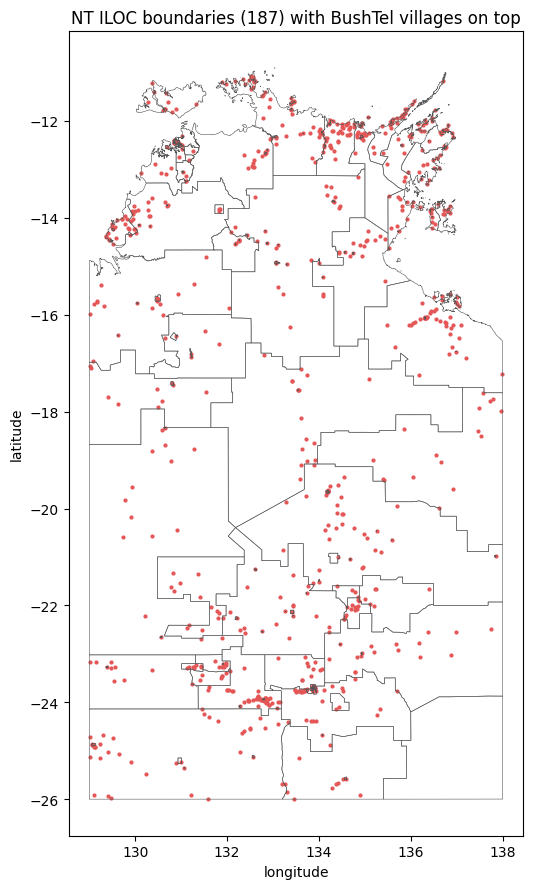

In [16]:
print("NT ILOC records:", len(iloc_polygons_gdf), "| CRS:", iloc_polygons_gdf.crs)
iloc_null = iloc_polygons_gdf[iloc_polygons_gdf["geometry"].isna() | iloc_polygons_gdf["geometry"].is_empty]
print(f"ILOC records with no polygon: {len(iloc_null)} -> {iloc_null['ILO_NAME21'].tolist()}")

iloc_area = pd.to_numeric(iloc_polygons_gdf["AREASQKM21"], errors="coerce").dropna()
print("\nILOC area (sq km) describe:")
print(iloc_area.describe())

iloc_real = iloc_polygons_gdf.dropna(subset=["geometry"]).to_crs("EPSG:4326")
fig, ax = plt.subplots(figsize=(7.5, 9))
iloc_real.boundary.plot(ax=ax, color="#555555", linewidth=0.4)
bushtel_communities_gdf.plot(ax=ax, color="#e45756", markersize=4)
ax.set_title(f"NT ILOC boundaries ({len(iloc_real)}) with BushTel villages on top")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["00a_iloc_map"] = fig

---
## E. Remoteness Area workbook

Counts of the remoteness classes for NT SA1s, and a map. Watch for the trap that "Outer
Regional" in the NT is almost entirely greater Darwin — lots of tiny urban SA1s — while
one Very Remote SA1 can be the size of Tasmania. Count and area tell opposite stories, so
this cell prints both, plus how the 792 villages fall across the classes (villages, not
SA1s, are what the gap work is about).

RA workbook, NT rows: 649

by SA1 count:
RA_NAME_2021
Outer Regional Australia                355
Very Remote Australia                   159
Remote Australia                        131
Migratory - Offshore - Shipping (NT)      3
No usual address (NT)                     1
Name: count, dtype: int64

by land area (sq km, Albers):
       1,249,587  (92.7%)  Very Remote Australia
          95,380  ( 7.1%)  Remote Australia
           3,168  ( 0.2%)  Outer Regional Australia
               0  ( 0.0%)  Migratory - Offshore - Shipping (NT)
               0  ( 0.0%)  No usual address (NT)

by BushTel village count:
RA_NAME_2021
Very Remote Australia       673
Remote Australia            106
Outer Regional Australia     13
Name: count, dtype: int64

-> 'Outer Regional' is a big share of SA1s but a tiny share of land and of villages;
   the remote-community story lives almost entirely in Remote + Very Remote.


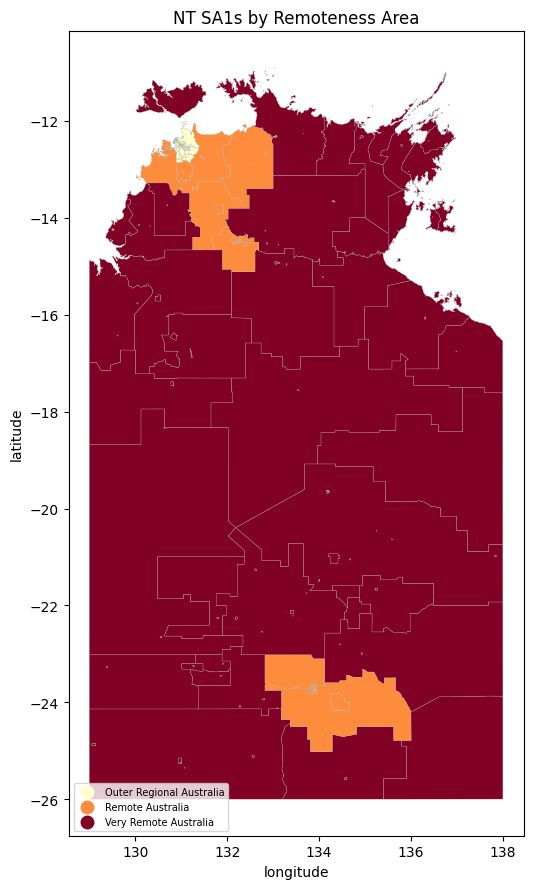

In [17]:
print("RA workbook, NT rows:", len(ra_nt))
print("\nby SA1 count:")
print(ra_nt["RA_NAME_2021"].value_counts())

# area-weighted: sum the SA1 Albers area per class
area_by_ra = (ra_nt.assign(km2=pd.to_numeric(ra_nt["AREA_ALBERS_SQKM"], errors="coerce"))
                    .groupby("RA_NAME_2021")["km2"].sum().sort_values(ascending=False))
print("\nby land area (sq km, Albers):")
for name, km2 in area_by_ra.items():
    print(f"  {km2:>14,.0f}  ({km2 / area_by_ra.sum():5.1%})  {name}")

# villages per remoteness class (village -> SA1 -> RA)
_v = gpd.sjoin(
    bushtel_communities_gdf.to_crs("EPSG:4326")[["community_id", "geometry"]],
    sa1_polygons_gdf.dropna(subset=["geometry"])[["SA1_CODE21", "geometry"]].to_crs("EPSG:4326"),
    how="left", predicate="within",
).merge(ra_nt[["SA1_CODE_2021", "RA_NAME_2021"]], left_on="SA1_CODE21", right_on="SA1_CODE_2021", how="left")
print("\nby BushTel village count:")
print(_v["RA_NAME_2021"].value_counts())
print("\n-> 'Outer Regional' is a big share of SA1s but a tiny share of land and of villages;")
print("   the remote-community story lives almost entirely in Remote + Very Remote.")

ra_map_gdf = sa1_polygons_gdf.merge(
    ra_nt[["SA1_CODE_2021", "RA_NAME_2021"]],
    left_on="SA1_CODE21", right_on="SA1_CODE_2021", how="left",
).dropna(subset=["geometry"])

fig, ax = plt.subplots(figsize=(7.5, 9))
ra_map_gdf.plot(ax=ax, column="RA_NAME_2021", legend=True, edgecolor="0.7", linewidth=0.2,
                cmap="YlOrRd", legend_kwds={"fontsize": 7, "loc": "lower left"})
ax.set_title("NT SA1s by Remoteness Area")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["00a_ra_remoteness_map"] = fig

---
## F. Data-quality list — what notebooks 01 & 02 must do

| # | issue found in this notebook | what the pipeline does about it |
|---|---|---|
| 1 | **No duplicate `community_id`.** 792 features, 792 distinct ids; the within-joins to SA1 and ILOC are 1:1 with 0 unmatched. The "793" was a header-inclusive line count. | nb 01 asserts `community_id` unique **and** count == 792; no dedupe step. |
| 2 | `population_count` present for only **457 / 792** ("Not recorded" for 335; "Based on ABS 2021 Census SA1" for 78, i.e. not a field figure). | nb 01 renames `population_count` → **`population_count_bushtel`** and `population_source` → `population_source_bushtel`; both are **kept but never used anywhere downstream** (not summed, not joined, not in any gap measure) — PROJECT_CONTEXT §2. |
| 3 | `community_aliases`: **180** rows hold the sentinel *"No aliases recorded with NTG DIPL"*; 612 hold real text; 376 are comma-separated multi-values. | nb 05/06 name-matching treats the sentinel as empty and splits the rest on comma. |
| 4 | Census SA1 code columns read as **int64** without `dtype=str` (e.g. `70101100101`), which then won't join to a string key. | Every notebook reads every SA1 code as `str` (PROJECT_CONTEXT). |
| 5 | **27** NT SA1s have `Tot_P_P == 0`, **34** have `< 5`, 67 have `< 50`. The zero-pop SA1s are mostly **urban non-residential** parcels (Darwin City, Palmerston, Larapinta), plus a few large remote polygons — and **4 of those large remote ones contain 30 inhabited BushTel outstations** (Tanami 8, Yuendumu-Anmatjere 11, Gulf 10, Sandover-Plenty 1; see B.3). | **Decision (revised 2026-09-06):** nb 02 **keeps all 649 rows** in `sa1_report` (`validate="1:1"`) and adds a boolean **`census_pop_suppressed = Tot_P_P < 5`**. The 34 suppressed rows are also written to `data/new_processed/area_with_population_lessthan_5.csv` as a side list. The 30 villages keep `sa1_code` and `pop_census_2021 = 0`. nb 07 guards ÷0. Report: census reports 0 for SA1s that are demonstrably inhabited — do not read "0" as "no gap". |
| 6 | G02 `Median_tot_hhd_inc_weekly` (**34**) and `Average_household_size` (**33**) are **0, not null** — ABS confidentiality suppression of small-count SA1s (they line up with `Tot_P_P < 5`). | nb 02 sets these `0 → NaN` in `sa1_report` (both columns) before any use. |
| 7 | SA1 shapefile: **4** NT codes have null geometry — `79797979991/2/3` (Migratory · Offshore · Shipping) and `79999949999` (No usual address). | CSV outputs carry 649 rows; GeoJSON outputs carry 645; nb 02 drops null geometry for the `.geojson` only, and says so. |
| 8 | ILOC shapefile: 189 NT records (2 with null geometry). It duplicates the region signal SA1 already provides and nothing downstream needs a second one. | **Decision 2026-09-06:** ILOC is **dropped** — nb 01/06 do not read it, `villages.csv` has no `iloc_code`/`iloc_name`, and the file is unticked in `DATASET_INVENTORY.md`. Shapefile left on disk (safe to delete). |
| 9 | SA1 key alignment: **649 identical codes** across SA1 shapefile, RA workbook, and Census G01/G02 (0 one-sided either way). | nb 02 merges on `sa1_code` with `validate="1:1"`. |
| 10 | RA workbook (NT): 355 Outer Regional, 131 Remote, 159 Very Remote, plus **4 non-substantive** classes (3 Migratory-Offshore-Shipping, 1 No usual address). | Carried through; excluded from remoteness-equity framing where they carry no population or geometry. |
| 11 | **"Outer Regional" ≠ regional bush.** Those 355 SA1s are ~1% of NT land and hold almost no BushTel villages — they are greater Darwin. Remote + Very Remote is where the remote-community question lives. | Report/prototype framing keys on Remote + Very Remote; per-class comparisons quote village counts, not SA1 counts. |
| 12 | CRS mismatch: BushTel is EPSG:4326, the ABS polygons are EPSG:7844 (≈ sub-metre apart). | nb 01 reprojects polygons to 4326 for the `within` join; later distance work uses EPSG:3577. |

### Guards — fail loudly if any premise above broke

In [18]:
ra_nt = ra_workbook_df[ra_workbook_df["STATE_NAME_2021"] == "Northern Territory"]

assert len(bushtel_communities_gdf) == 792, "expected 792 BushTel features"
assert bushtel_communities_gdf["community_id"].is_unique, "community_id not unique"
assert len(census_g01_sa1_df) == 649 and len(census_g02_sa1_df) == 649, "expected 649 census SA1 rows"

_codes_shp = set(sa1_polygons_gdf["SA1_CODE21"])
assert _codes_shp == set(ra_nt["SA1_CODE_2021"]) == set(census_g01_sa1_df["SA1_CODE_2021"]), "SA1 key mismatch"
assert (sa1_polygons_gdf["geometry"].isna() | sa1_polygons_gdf["geometry"].is_empty).sum() == 4, \
    "expected 4 SA1 codes with null geometry"

ASSERTS_PASSED = 5
print(f"{ASSERTS_PASSED} guards passed")

5 guards passed


In [19]:
# Second-to-last cell: summary print.
print("00a EDA - summary")
print("-" * 60)
print(f"BushTel        : 792 features, {bushtel_communities_gdf['community_id'].nunique()} distinct community_id  (no duplicate)")
print(f"Census G01/G02 : {len(census_g01_sa1_df)} / {len(census_g02_sa1_df)} SA1 rows; "
      f"{int((census_g01_sa1_df['Tot_P_P']==0).sum())} zero-pop SA1s; "
      f"{int((pd.to_numeric(census_g02_sa1_df['Median_tot_hhd_inc_weekly'],errors='coerce')==0).sum())} income values ABS-suppressed to 0")
print(f"SA1 polygons   : {len(sa1_polygons_gdf)} NT rows, 4 with null geometry (645 mappable)")
print(f"ILOC polygons  : {len(iloc_polygons_gdf)} NT rows, 2 with null geometry")
print(f"RA workbook    : {len(ra_nt)} NT SA1s; SA1 key aligns 1:1 across shp / RA / census (649)")
print("dropped        : nothing (read-only EDA)")
print(f"asserts        : {ASSERTS_PASSED} passed")
print(f"plots          : {len(eda_figures)} figures queued for docs/eda/ (written by the next cell)")

00a EDA - summary
------------------------------------------------------------
BushTel        : 792 features, 792 distinct community_id  (no duplicate)
Census G01/G02 : 649 / 649 SA1 rows; 27 zero-pop SA1s; 34 income values ABS-suppressed to 0
SA1 polygons   : 649 NT rows, 4 with null geometry (645 mappable)
ILOC polygons  : 189 NT rows, 2 with null geometry
RA workbook    : 649 NT SA1s; SA1 key aligns 1:1 across shp / RA / census (649)
dropped        : nothing (read-only EDA)
asserts        : 5 passed
plots          : 8 figures queued for docs/eda/ (written by the next cell)


In [20]:
# Last cell: the only writes this notebook makes — PNGs to docs/eda/. No data files.
for name, fig in eda_figures.items():
    path = EDA_PLOT_DIR / f"{name}.png"
    fig.savefig(path, dpi=120, bbox_inches="tight")
    print("wrote", path)

wrote docs\eda\00a_bushtel_community_type_counts.png
wrote docs\eda\00a_bushtel_villages_by_type_map.png


wrote docs\eda\00a_census_totpp_hist.png


wrote docs\eda\00a_census_empty_tiny_sa1_map.png
wrote docs\eda\00a_g02_income_hhsize_hist.png


wrote docs\eda\00a_sa1_area_hist.png
wrote docs\eda\00a_iloc_map.png


wrote docs\eda\00a_ra_remoteness_map.png
